# Task 2: Video Game "Hit" Prediction

## Introduction

The objective of this task is to predict the commercial performance of video games using
metadata available before or at release time (platform, genre, publisher/developer profile,
release year, and critic score availability).

The primary task is formulated as a **binary classification problem**, where a game is
classified as a *Hit* or *Non-Hit* based on its total global sales. This formulation reflects
real market conditions and results in a naturally **imbalanced dataset**, requiring
appropriate evaluation metrics and modeling strategies.

As an extension of this work, we also consider a **regression task** aimed at predicting
**global sales as a continuous value**. While classification supports early success
screening, regression provides additional insight into the expected magnitude of sales,
which is useful for forecasting and planning purposes.

---
### Workflow overview

This notebook is organized as follows:
1. Load and clean game sales data
2. Merge with publisher/developer statistics
3. Engineer advanced features
4. Train multiple classifiers with optimized hyperparameters
5. Evaluate and diagnose the models
6. Regression modeling and evaluating

# 1.Import libraries and setup

In [95]:
# =========================
# Imports & Settings
# =========================
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

RANDOM_STATE = 42

## 2. Data Preparation

This section does:
- Cleaning (types, missing values, Data Exploration & Quality Check)
- Feature engineering
- Target creation (hit /miss )


In [96]:
# =========================
# 2.1 Load data
# =========================
GAMES_RAW_PATH = "/data/vgchartz-2024.csv"
PUB_PATH      = "/data/publishers.csv"

games_raw = pd.read_csv(GAMES_RAW_PATH)
pub_raw   = pd.read_csv(PUB_PATH)

# Normalize column names
games_raw.columns = games_raw.columns.str.strip().str.lower()
pub_raw.columns   = pub_raw.columns.str.strip().str.lower()

print("games_raw:", games_raw.shape)
print("pub_raw  :", pub_raw.shape)
print('='*70)
games_raw.info()

games_raw: (64016, 14)
pub_raw  : (260, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


# ***Missing Value Analysis***

In [97]:
missing_summary = pd.DataFrame({
    'Missing_Count': games_raw.isnull().sum(),
    'Percentage': (games_raw.isnull().sum() / len(games_raw)) * 100
})
missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)


,Missing_Count,Percentage
critic_score,57338,89.568233
jp_sales,57290,89.493252
na_sales,51379,80.259623
pal_sales,51192,79.967508
other_sales,48888,76.368408
last_update,46137,72.071045
total_sales,45094,70.441765
release_date,7051,11.014434
developer,17,0.026556


- Column names are converted to lowercase and stripped of extra spaces to ensure consistency.
- Text columns (title, console, genre, publisher, developer) are cleaned by removing empty strings and invalid values such as "nan" or "None".
- Any row with missing  `total sales` is dropped as it does not represent the commercial games.

In [98]:
# =========================
# 2.2 Basic cleaning (games)
# =========================
games = games_raw.copy()

# Normalize text columns
text_cols = ["title","console","genre","publisher","developer"]
for c in text_cols:
    if c in games.columns:
        games[c] = games[c].astype(str).str.strip()
        games[c] = games[c].replace({"nan": np.nan, "none": np.nan, "": np.nan})

# Sales columns (needed ONLY to build target, then removed from features)
sales_cols = ["total_sales","na_sales","jp_sales"]

# Drop rows where total sales are missing (cannot label)
before = len(games)
games = games.dropna(subset=sales_cols, how="all").copy()
print("Dropped rows (all sales missing):", before - len(games))

# Convert sales to numeric
for c in sales_cols:
    games[c] = pd.to_numeric(games[c], errors="coerce")

# If total_sales missing, recompute from regions (safe for labeling only)
mask = games["total_sales"].isna()
if mask.sum() > 0:
    games.loc[mask, ["na_sales","jp_sales","pal_sales","other_sales"]] = (
        games.loc[mask, ["na_sales","jp_sales","pal_sales","other_sales"]].fillna(0)
    )
    games.loc[mask, "total_sales"] = games.loc[mask, ["na_sales","jp_sales","pal_sales","other_sales"]].sum(axis=1)

games = games.dropna(subset=["total_sales"]).copy()
print("After sales cleaning:", games.shape)

Dropped rows (all sales missing): 45094
After sales cleaning: (18922, 14)


As we have many games that does not have the critic score and it shows the strongest correlation with the target variable (game hit) among all features, ie;games that receive higher critic scores tend to achieve higher sales and are more likely to become commercial hits.

For this reseon we have decided to create an other feature `has_critic_score`, and  `critic_score` missing values were imputed by the mean critic score of the same genre.

In [99]:
# =========================
# 2.3 Critic score handling
# =========================
# IMPORTANT:
# We do NOT impute critic_score here, because imputing from the full dataset
# would let information from the test set influence the training preprocessing.
# We only:
#   1) create an indicator has_critic_score
#   2) coerce critic_score to numeric (keep NaN for now/ will be imputed later with the mean value for each genre)
# The actual imputation is done later *after the train/test split* using train-only statistics.

games["has_critic_score"] = games["critic_score"].notna().astype(int)
games["critic_score"] = pd.to_numeric(games["critic_score"], errors="coerce")

print("Missing critic_score (before train-only imputation):", games["critic_score"].isna().sum())
print("Has critic score rate:", games["has_critic_score"].mean())


Missing critic_score (before train-only imputation): 14796
Has critic score rate: 0.21805305993023993


 two other features are identified form release date  which are: `release_year` + `game_age`.

In [100]:
# =========================
# 2.4 Release date → release_year + game_age
# =========================
games["release_date"] = pd.to_datetime(games["release_date"], errors="coerce")
games["release_year"] = games["release_date"].dt.year

# Fill missing years by median year
games["release_year"] = games["release_year"].fillna(games["release_year"].median())

CURRENT_YEAR = 2025
games["game_age"] = CURRENT_YEAR - games["release_year"]

# Drop raw date (kept only engineered features)
games = games.drop(columns=["release_date"], errors="ignore")

We define `target = 1` for the games by **total_sales >= 1M**  , and `target = 0` otherwise.


In [101]:
# =========================
# 2.5 Target creation (total_sales > 1M)
# =========================
p85 = games["total_sales"].quantile(0.85)
games["target"] = (games["total_sales"] >= p85).astype(int)

print("Target distribution:")
display(games["target"].value_counts())
display(games["target"].value_counts(normalize=True))

Target distribution:


,count
target,
0,16052
1,2870


,proportion
target,
0,0.848325
1,0.151675


In [102]:
# =========================
# 2.6 Remove leakage columns from FEATURES (keep only for inspection if you want)
# =========================
# We'll keep sales columns in games for now, but later we will build X by explicitly selecting safe features.
# Also remove obvious non-features
drop_cols = ["img","last_update"]
games = games.drop(columns=[c for c in drop_cols if c in games.columns], errors="ignore")

# Remove exact duplicates
games = games.drop_duplicates().copy()
print("Final games shape:", games.shape)

Final games shape: (18919, 15)


In [103]:
print(pub_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       260 non-null    int64  
 1   publisher                260 non-null    object 
 2   classification           260 non-null    object 
 3   released_games           260 non-null    int64  
 4   unreleased_games         260 non-null    int64  
 5   total_revenue            260 non-null    float64
 6   avg_revenue_per_game     260 non-null    float64
 7   median_revenue_per_game  260 non-null    float64
 8   hq_country               151 non-null    object 
 9   pct_inhouse              260 non-null    float64
 10  action                   260 non-null    float64
 11  adventure                260 non-null    float64
 12  arcade                   260 non-null    float64
 13  casino                   260 non-null    float64
 14  lifestyle                2

##  4.Publishers Dataset Description

The publishers dataset provides **publisher-level information** that complements the
game-level data used in this project. Each row represents a **single publisher** and
summarizes its market profile, experience, revenue, and genre specialization.

## *Dataset contents*

The dataset contains the following groups of attributes:

**1. Publisher identity**
- `publisher`: Publisher name (used as the merge key)

**2. Publisher classification**
- `classification`: Categorical label describing the publisher type
  (e.g., AAA, AA, Indie)

**3. Experience indicators**
- `released_games`: Number of released games
- `unreleased_games`: Number of announced but unreleased games
- `pct_inhouse`: Percentage of games developed internally

**4. Revenue indicators**
- `total_revenue`
- `avg_revenue_per_game`
- `median_revenue_per_game`

**5. Genre distribution**
- Percentage-based columns representing the publisher’s catalog composition:
  `action, adventure, rpg, shooter, sports, racing, simulation, strategy,
   puzzle, arcade, lifestyle, casino, tabletop`

These genre values describe how strongly a publisher is associated with
each genre.

  ## *Publisher Feature Engineering*

To make the publishers dataset suitable for classification modeling, several
derived features were created:

- **`publisher_main_genre`**  
  The genre with the highest percentage in the publisher’s catalog.

- **`publisher_second_genre`**  
  The second most represented genre.

- **`publisher_focus`**  
  The maximum genre percentage, measuring how specialized the publisher is.

- **`publisher_experience`**  
  Computed as:
  released_games − unreleased_games

- **`publisher_revenue_tier`**  
  Discretization of total revenue into quartiles:
  {low, mid, high, very_high}
---

### *Motivation for Using Publisher-Level Features*

Initial predictive models based on only game-level attributes  
*(console, genre, developer, release year, critic score, etc.)*  
showed limited performance and signs of overfitting, indicating that important
structural information was missing.

The conducted earlier clustering analysis  highlighted the strong
influence of **publisher-related characteristics**, particularly publisher
classification, revenue scale, and genre specialization, on game success.

These results suggest that commercial success is not driven by individual
game properties, but also by the **strategic position, resources, and market focus
of the publisher**.

Therefore, incorporating publisher-level features allows the predictive model to
better capture market structure effects and improves its ability to generalize to
new games.

## *Merging Games and Publishers Datasets*

The games and publishers datasets were merged using the **publisher name**
as a common key.

- Merge key: `publisher`
- Merge type: **left join**

This ensures that:
- All games are preserved
- Publisher information is added when available

### Handling missing publisher information

Not all games have matching publisher metadata. Instead of removing these
rows, the following strategy was applied:

- `publisher_known` = 1 if publisher data is available, 0 otherwise
- Missing `classification` values are filled with `"indie"`
- Missing publisher-related attributes are filled with `"unknown"`

This allows the model to learn differences between games published by
well-known publishers and those released by unknown or independent ones.


In [104]:
pub = pub_raw.copy()
pub_missing_summary = pd.DataFrame({
    'Missing_Count': pub.isnull().sum(),
    'Percentage': (pub.isnull().sum() / len(pub)) * 100
})
pub_missing_summary[pub_missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

,Missing_Count,Percentage
hq_country,109,41.923077


In [218]:
# =========================
# 2.7 Prepare publishers dataset + engineered publisher features
# =========================
# Drop unused
if "hq_country" in pub.columns:
    pub = pub.drop(columns=["hq_country"])

# Genre columns in publishers file
genre_cols = [
    'action','adventure','arcade','casino','lifestyle','puzzle',
    'racing','rpg','shooter','simulation','sports','strategy','tabletop'
]

# Ensure numeric genre scores
for c in genre_cols:
    pub[c] = pd.to_numeric(pub[c], errors="coerce").fillna(0)

# Publisher main/second genre + focus
pub["publisher_main_genre"] = pub[genre_cols].idxmax(axis=1)
pub["publisher_second_genre"] = pub[genre_cols].apply(lambda r: r.sort_values(ascending=False).index[1], axis=1)
pub["publisher_focus"] = pub[genre_cols].max(axis=1)

# Revenue tier
pub["total_revenue"] = pd.to_numeric(pub["total_revenue"], errors="coerce").fillna(0)
pub["publisher_revenue_tier"] = pd.qcut(
    pub["total_revenue"],
    q=4,
    labels=["low","mid","high","very_high"],
    duplicates="drop"
).astype(str)

# Normalize publisher names (simple normalization)
games["publisher"] = games["publisher"].astype(str).str.strip().str.lower()
pub["publisher"]   = pub["publisher"].astype(str).str.strip().str.lower()

# Merge (left join: keep all games)
merged = games.merge(pub, on="publisher", how="left", suffixes=("", "_pub"))
print("Merged shape:", merged.shape)

# Add 'publisher_known' and safe fills for missing publisher columns
merged["publisher_known"] = merged["classification"].notna().astype(int)

# If publisher profile missing, we set a default label for reporting/features.
# NOTE: This is not "truth"; it's a placeholder category.
merged["classification"] = merged["classification"].fillna("indie")
merged["publisher_main_genre"] = merged["publisher_main_genre"].fillna("unknown")
merged["publisher_revenue_tier"] = merged["publisher_revenue_tier"].fillna("unknown")

print("Publisher known rate:", merged["publisher_known"].mean())

Merged shape: (18919, 40)
Publisher known rate: 0.35895131878006237


In [219]:
# =========================
# 2.8 Genre mapping (games genre → publisher genre taxonomy)
# =========================
genre_mapping = {
    "Action": "action",
    "Adventure": "adventure",
    "Role-Playing": "rpg",
    "RPG": "rpg",
    "Shooter": "shooter",
    "Sports": "sports",
    "Racing": "racing",
    "Simulation": "simulation",
    "Strategy": "strategy",
    "Puzzle": "puzzle",
    "Platform": "arcade",
    "Fighting": "arcade",
    "Misc": "lifestyle",
    "Action-Adventure": "action",
    "Music": "lifestyle",
    "MMO": "rpg",
    "Visual Novel": "adventure",
    "Party": "lifestyle",
    "Board Game": "tabletop",
}

merged["genre_mapped"] = merged["genre"].map(genre_mapping).fillna("unknown")

# Publisher-genre match
merged["publisher_genre_match"] = (
    (merged["genre_mapped"] == merged["publisher_main_genre"]) &
    merged["publisher_main_genre"].notna()
).astype(int)

# Publisher experience
merged["publisher_experience"] = (
    pd.to_numeric(merged["released_games"], errors="coerce").fillna(0)
    - pd.to_numeric(merged["unreleased_games"], errors="coerce").fillna(0)
)

# Era
merged["era"] = pd.cut(
    merged["release_year"],
    bins=[1980,1995,2005,2015,2025],
    labels=["retro","early","mid","modern"]
).astype(object).fillna("early")

print("Unmapped genre rows:", (merged["genre_mapped"] == "unknown").sum())

Unmapped genre rows: 5


## 4. Train/Test Split (stratified)

**Important:** We compute developer statistics/ critic_score imputation with the mean using *only the training set* to avoid leakage.

In [220]:
# =========================
# 3.1 Train/test split (Stratified)
# =========================
y = merged["target"].astype(int)

# We'll build X later by selecting features; for now split indices safely
train_idx, test_idx = train_test_split(
    merged.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

train_df = merged.loc[train_idx].copy()
test_df  = merged.loc[test_idx].copy()

print("Train:", train_df.shape, "Test:", test_df.shape)
print("Train hit rate:", train_df["target"].mean(), "Test hit rate:", test_df["target"].mean())

Train: (15135, 45) Test: (3784, 45)
Train hit rate: 0.15163528245787908 Test hit rate: 0.15169133192389006


In [221]:
# =========================
# 3.2 Developer stats (train-only) to avoid leakage
# =========================
# success rate per developer in TRAIN
dev_train = train_df["developer"].fillna("unknown").astype(str)

dev_success = train_df.groupby(dev_train)["target"].mean()
dev_count   = dev_train.value_counts()

global_hit_rate = train_df["target"].mean()

# map to train
train_df["dev_success_rate"] = dev_train.map(dev_success).fillna(global_hit_rate)
train_df["dev_game_count"]   = dev_train.map(dev_count).fillna(0)

# map to test using TRAIN statistics only
dev_test = test_df["developer"].fillna("unknown").astype(str)
test_df["dev_success_rate"] = dev_test.map(dev_success).fillna(global_hit_rate)
test_df["dev_game_count"]   = dev_test.map(dev_count).fillna(0)

In [222]:
# =========================
# 3.3 Critic score imputation
# =========================

# Ensure numeric
train_df["critic_score"] = pd.to_numeric(train_df["critic_score"], errors="coerce")
test_df["critic_score"]  = pd.to_numeric(test_df["critic_score"], errors="coerce")

# (Optional but recommended) avoid issues if genre itself is missing
train_df["genre"] = train_df["genre"].fillna("Unknown")
test_df["genre"]  = test_df["genre"].fillna("Unknown")

# Compute train-only medians
genre_median_train = train_df.groupby("genre")["critic_score"].median()

# If global median is NaN (edge case: all missing), use 0
global_median_train = train_df["critic_score"].median()
if pd.isna(global_median_train):
    global_median_train = 0

def impute_critic_score(df):
    # 1) fill missing using genre median (may still produce NaN if that genre median is NaN)
    filled = df["critic_score"].fillna(df["genre"].map(genre_median_train))
    # 2) fill any remaining NaN using global train median
    filled = filled.fillna(global_median_train)
    # 3) final safety (should be unnecessary, but keeps it robust)
    filled = filled.fillna(0)
    return filled

train_df["critic_score"] = impute_critic_score(train_df)
test_df["critic_score"]  = impute_critic_score(test_df)

print("Missing critic_score after train-only imputation:")
print("  - Train:", train_df["critic_score"].isna().sum())
print("  - Test :", test_df["critic_score"].isna().sum())


Missing critic_score after train-only imputation:
  - Train: 0
  - Test : 0


## 6. Preprocessing Pipeline (numeric vs categorical )

We create one consistent preprocessing pipeline:
- Numeric: median imputation
- Categorical: most-frequent imputation + one-hot encoding.

In [223]:
# =========================
# 4.1 Select SAFE features (no sales columns)
# =========================
import numpy as np

UNKNOWN_LABEL = "Unknown"
OTHER_LABEL = "Other"

# Ensure base columns exist as strings
train_df["publisher"] = train_df["publisher"].fillna(UNKNOWN_LABEL).astype(str)
test_df["publisher"]  = test_df["publisher"].fillna(UNKNOWN_LABEL).astype(str)

train_df["developer"] = train_df["developer"].fillna(UNKNOWN_LABEL).astype(str)
test_df["developer"]  = test_df["developer"].fillna(UNKNOWN_LABEL).astype(str)

# -------------------------
# Top-10 based on TRAIN ONLY (excluding 'Unknown')
# -------------------------
top10_publishers = (
    train_df.loc[train_df["publisher"] != UNKNOWN_LABEL, "publisher"]
    .value_counts()
    .head(20)
    .index
    .tolist()
)

top10_developers = (
    train_df.loc[train_df["developer"] != UNKNOWN_LABEL, "developer"]
    .value_counts()
    .head(20)
    .index
    .tolist()
)

def map_top10_keep_unknown(series, top10_list):
    # Keep Unknown as Unknown.
    # Keep Top10 values as themselves.
    # Everything else -> Other.
    return np.where(
        series == UNKNOWN_LABEL,
        UNKNOWN_LABEL,
        np.where(series.isin(top10_list), series, OTHER_LABEL)
    )

# Create new categorical features
train_df["publisher_top10"] = map_top10_keep_unknown(train_df["publisher"], top10_publishers)
test_df["publisher_top10"]  = map_top10_keep_unknown(test_df["publisher"],  top10_publishers)

train_df["developer_top10"] = map_top10_keep_unknown(train_df["developer"], top10_developers)
test_df["developer_top10"]  = map_top10_keep_unknown(test_df["developer"],  top10_developers)

print("Top-10 publishers (excluding Unknown):", top10_publishers)
print("Top-10 developers (excluding Unknown):", top10_developers)

print("\nCounts check (developer_top10):")
print(train_df["developer_top10"].value_counts().head(15))

FEATURES = [
    # numeric
    "critic_score","has_critic_score","release_year","game_age",
    "publisher_known","publisher_genre_match","publisher_experience","publisher_focus",
    "dev_success_rate","dev_game_count",
    # categorical
    "genre_mapped","publisher_revenue_tier","classification","console",
    "publisher_top10","developer_top10",
    "publisher", "developer",

]


# Build X/y from train/test
X_train = train_df[FEATURES].copy()
y_train = train_df["target"].astype(int)

X_test  = test_df[FEATURES].copy()
y_test  = test_df["target"].astype(int)

# Define numeric vs categorical
NUM_COLS = [
    "critic_score","has_critic_score","release_year", "game_age",
    "publisher_known","publisher_genre_match","publisher_experience","publisher_focus",
    "dev_success_rate","dev_game_count"
]
CAT_COLS = ["genre_mapped","publisher_revenue_tier","classification","console",
            # "publisher_top10",
            # "developer_top10",
            # "publisher",
            # "developer"
            ]


# Safety: ensure correct types (avoid pandas Categorical issues)
for c in CAT_COLS:
    X_train[c] = X_train[c].astype(object)
    X_test[c]  = X_test[c].astype(object)

for c in NUM_COLS:
    X_train[c] = pd.to_numeric(X_train[c], errors="coerce")
    X_test[c]  = pd.to_numeric(X_test[c], errors="coerce")

print("X_train:", X_train.shape, "X_test:", X_test.shape)

Top-10 publishers (excluding Unknown): ['ubisoft', 'activision', 'electronic arts', 'konami', 'thq', 'sega', 'sony computer entertainment', 'ea sports', 'capcom', 'nintendo', 'atari', 'namco bandai', 'namco bandai games', 'midway games', 'eidos interactive', 'majesco', 'square enix', 'atlus', 'disney interactive studios', 'unknown']
Top-10 developers (excluding Unknown): ['Konami', 'Capcom', 'EA Canada', 'Bandai Namco Games', 'Ubisoft', 'EA Tiburon', 'Ubisoft Montreal', 'Sega', "Traveller's Tales", 'Omega Force', 'Idea Factory', 'Visual Concepts', 'Namco Bandai Games', 'Namco', 'Square Enix', 'Hudson Soft', 'Vicarious Visions', 'Activision', 'Nippon Ichi Software', 'Koei']

Counts check (developer_top10):
developer_top10
Other                 12164
Unknown                 348
Konami                  333
Capcom                  233
EA Canada               216
Ubisoft                 161
Bandai Namco Games      161
EA Tiburon              154
Ubisoft Montreal        138
Sega             

In [224]:
# =========================
# 4.2 Preprocessing pipeline
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) # Added sparse_output=False
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_COLS),
        ("cat", categorical_transformer, CAT_COLS),
    ],
    remainder="drop"
)

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['critic_score', 'has_critic_score',
                                  'release_year', 'game_age', 'publisher_known',
                                  'publisher_genre_match',
                                  'publisher_experience', 'publisher_focus',
                                  'dev_success_rate', 'dev_game_count']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['genre_mapped', 'publisher_revenue_tier',
                                  'classification', 'console'])])

## 7. Modeling & Sampling Strategies

We run several models:
- LogisticRegression
- Baseline (no sampling)

With different ways:
- Under-sampling
- Over-sampling (ROS)
- SMOTE

We evaluate on the same held-out test set with:
- F1 (class 1)
- PR-AUC (average precision)
- ROC-AUC (optional)

In [225]:
# =========================
# Helper: evaluate a fitted model
# =========================
def eval_model(model, X_test, y_test, name):
    pred = model.predict(X_test)
    print("\n===", name, "===")
    print("Confusion:\n", confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=4))

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        print("ROC-AUC:", roc_auc_score(y_test, proba))
        print("PR-AUC :", average_precision_score(y_test, proba))

In [226]:
# =========================
# 5.1 decision tree models
# =========================
baseline_dt = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

baseline_dt.fit(X_train, y_train)
eval_model(baseline_dt, X_test, y_test, "Baseline DecisionTree")



=== Baseline DecisionTree ===
Confusion:
 [[2539  671]
 [ 133  441]]
              precision    recall  f1-score   support

           0     0.9502    0.7910    0.8633      3210
           1     0.3966    0.7683    0.5231       574

    accuracy                         0.7875      3784
   macro avg     0.6734    0.7796    0.6932      3784
weighted avg     0.8662    0.7875    0.8117      3784

ROC-AUC: 0.8285727853940756
PR-AUC : 0.4764114696435003


In [227]:
# =========================
# 5.2 Baseline models
# =========================
baseline_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000, solver="liblinear", class_weight="balanced"))
])

baseline_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ))
])

baseline_lr.fit(X_train, y_train)
eval_model(baseline_lr, X_test, y_test, "Baseline LogisticRegression")

baseline_rf.fit(X_train, y_train)
eval_model(baseline_rf, X_test, y_test, "Baseline RandomForest")


=== Baseline LogisticRegression ===
Confusion:
 [[2659  551]
 [ 163  411]]
              precision    recall  f1-score   support

           0     0.9422    0.8283    0.8816      3210
           1     0.4272    0.7160    0.5352       574

    accuracy                         0.8113      3784
   macro avg     0.6847    0.7722    0.7084      3784
weighted avg     0.8641    0.8113    0.8291      3784

ROC-AUC: 0.8567146439154645
PR-AUC : 0.5345491884692857

=== Baseline RandomForest ===
Confusion:
 [[2482  728]
 [ 118  456]]
              precision    recall  f1-score   support

           0     0.9546    0.7732    0.8544      3210
           1     0.3851    0.7944    0.5188       574

    accuracy                         0.7764      3784
   macro avg     0.6699    0.7838    0.6866      3784
weighted avg     0.8682    0.7764    0.8035      3784

ROC-AUC: 0.8561282251674319
PR-AUC : 0.5971977137606468


In [228]:
# =========================
# 5.3 Under-sampling + RandomForest
# =========================
under_rf = ImbPipeline(steps=[
    ("prep", preprocess),
    ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

under_rf.fit(X_train, y_train)
eval_model(under_rf, X_test, y_test, "UnderSampling + RandomForest")


=== UnderSampling + RandomForest ===
Confusion:
 [[2342  868]
 [ 106  468]]
              precision    recall  f1-score   support

           0     0.9567    0.7296    0.8279      3210
           1     0.3503    0.8153    0.4901       574

    accuracy                         0.7426      3784
   macro avg     0.6535    0.7725    0.6590      3784
weighted avg     0.8647    0.7426    0.7766      3784

ROC-AUC: 0.8523179958101317
PR-AUC : 0.5795983897713448


In [229]:
# =========================
# 5.4 Over-sampling (ROS) + RandomForest
# =========================
ros_rf = ImbPipeline(steps=[
    ("prep", preprocess),
    ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

ros_rf.fit(X_train, y_train)
eval_model(ros_rf, X_test, y_test, "ROS + RandomForest")


=== ROS + RandomForest ===
Confusion:
 [[2514  696]
 [ 122  452]]
              precision    recall  f1-score   support

           0     0.9537    0.7832    0.8601      3210
           1     0.3937    0.7875    0.5250       574

    accuracy                         0.7838      3784
   macro avg     0.6737    0.7853    0.6925      3784
weighted avg     0.8688    0.7838    0.8092      3784

ROC-AUC: 0.8591685933548253
PR-AUC : 0.6052076737682033


In [230]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        min_samples_leaf=30,
        random_state=RANDOM_STATE
    ))
])

hgb.fit(X_train, y_train)
eval_model(hgb, X_test, y_test, "HistGradientBoosting")



=== HistGradientBoosting ===
Confusion:
 [[3092  118]
 [ 323  251]]
              precision    recall  f1-score   support

           0     0.9054    0.9632    0.9334      3210
           1     0.6802    0.4373    0.5323       574

    accuracy                         0.8835      3784
   macro avg     0.7928    0.7003    0.7329      3784
weighted avg     0.8713    0.8835    0.8726      3784

ROC-AUC: 0.8534436158780814
PR-AUC : 0.5767792571103457


In [244]:
# =========================
# 5.5 SMOTE + RandomForestClassifier
# =========================
smote_rf = ImbPipeline(steps=[
    ("prep", preprocess),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

smote_rf.fit(X_train, y_train)
eval_model(smote_rf, X_test, y_test, "SMOTE + RandomForest")


=== SMOTE + RandomForest ===
Confusion:
 [[2789  421]
 [ 175  399]]
              precision    recall  f1-score   support

           0     0.9410    0.8688    0.9035      3210
           1     0.4866    0.6951    0.5725       574

    accuracy                         0.8425      3784
   macro avg     0.7138    0.7820    0.7380      3784
weighted avg     0.8720    0.8425    0.8533      3784

ROC-AUC: 0.8620260618494036
PR-AUC : 0.6055889555437457


In [241]:
# =========================
# 5.5 SMOTE + HistGradientBoostingClassifier
# =========================
smote_GB = ImbPipeline(steps=[
    ("prep", preprocess),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("clf", HistGradientBoostingClassifier(

        learning_rate=0.05,
        max_iter=400,
        min_samples_leaf=30,
        random_state=RANDOM_STATE
    ))
])

smote_GB.fit(X_train, y_train)
eval_model(smote_GB, X_test, y_test, "SMOTE + boost")


=== SMOTE + boost ===
Confusion:
 [[3001  209]
 [ 256  318]]
              precision    recall  f1-score   support

           0     0.9214    0.9349    0.9281      3210
           1     0.6034    0.5540    0.5777       574

    accuracy                         0.8771      3784
   macro avg     0.7624    0.7444    0.7529      3784
weighted avg     0.8732    0.8771    0.8749      3784

ROC-AUC: 0.8493812888729688
PR-AUC : 0.5776614555520316


## 6. Results: final comparison table

We store the main metrics (F1 for class 1, PR-AUC, ROC-AUC) for each approach.

In [246]:
# =========================
# 6.1 Collect results into a table
# =========================
from sklearn.metrics import f1_score

def get_metrics(model, X_test, y_test):
    pred = model.predict(X_test)
    out = {}
    out["f1_hit"] = f1_score(y_test, pred, pos_label=1)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        out["pr_auc"]  = average_precision_score(y_test, proba)
        out["roc_auc"] = roc_auc_score(y_test, proba)
    else:
        out["pr_auc"] = np.nan
        out["roc_auc"] = np.nan
    return out

models = {
    "Baseline LR": baseline_lr,
    "Baseline RF": baseline_rf,
    "SMOTE + GB": smote_GB,
    "ROS + RF": ros_rf,
    "SMOTE + RF": smote_rf,
}

rows = []
for name, mdl in models.items():
    m = get_metrics(mdl, X_test, y_test)
    rows.append({"model": name, **m})

results_df = pd.DataFrame(rows).sort_values("pr_auc", ascending=False)
results_df

,model,f1_hit,pr_auc,roc_auc
4,SMOTE + RF,0.572453,0.605589,0.862026
3,ROS + RF,0.524971,0.605208,0.859169
1,Baseline RF,0.518771,0.597198,0.856128
2,SMOTE + GB,0.577657,0.577661,0.849381
0,Baseline LR,0.535156,0.534549,0.856715


##  7. Cross-Validation (SMOTE + RandomForest) — PR-AUC mean & std

We run Stratified K-Fold CV on training data only.
Metric: **average_precision** (PR-AUC).

In [247]:
# =========================
# 7.1 SMOTE + RandomForest cross-validation
# =========================
smote_rf = ImbPipeline(steps=[
    ("prep", preprocess),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    smote_rf,
    X_train, y_train,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

print("PR-AUC scores:", cv_scores)
print("Mean PR-AUC:", cv_scores.mean())
print("Std  PR-AUC:", cv_scores.std())

PR-AUC scores: [0.67453193 0.66530638 0.6405933  0.64332824 0.63500718]
Mean PR-AUC: 0.651753407451164
Std  PR-AUC: 0.015352601424210566


# 8.Model Evaluation






In [248]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    classification_report
)
from sklearn.model_selection import learning_curve
import joblib

# Where to save artifacts
os.makedirs("../models", exist_ok=True)


In [249]:
# =========================
# 1) Evaluate ALL models consistently
# =========================

def compute_all_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "Test Accuracy":  accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall":    recall_score(y_test, y_pred, zero_division=0),
        "Test F1":        f1_score(y_test, y_pred, zero_division=0),
    }

    # Probability-based metrics (if available)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        metrics["Test ROC-AUC"] = roc_auc_score(y_test, y_proba)
        metrics["Test PR-AUC"]  = average_precision_score(y_test, y_proba)
    else:
        metrics["Test ROC-AUC"] = np.nan
        metrics["Test PR-AUC"]  = np.nan

    return metrics

eval_rows = []
for name, mdl in models.items():
    m = compute_all_metrics(mdl, X_test, y_test)
    eval_rows.append({"Model": name, **m})

eval_results_df = pd.DataFrame(eval_rows).sort_values(["Test PR-AUC", "Test F1"], ascending=False)
eval_results_df


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
4,SMOTE + RF,0.842495,0.486585,0.695122,0.572453,0.862026,0.605589
3,ROS + RF,0.783827,0.393728,0.787456,0.524971,0.859169,0.605208
1,Baseline RF,0.776427,0.385135,0.794425,0.518771,0.856128,0.597198
2,SMOTE + GB,0.877114,0.603416,0.554007,0.577657,0.849381,0.577661
0,Baseline LR,0.811311,0.427235,0.716028,0.535156,0.856715,0.534549


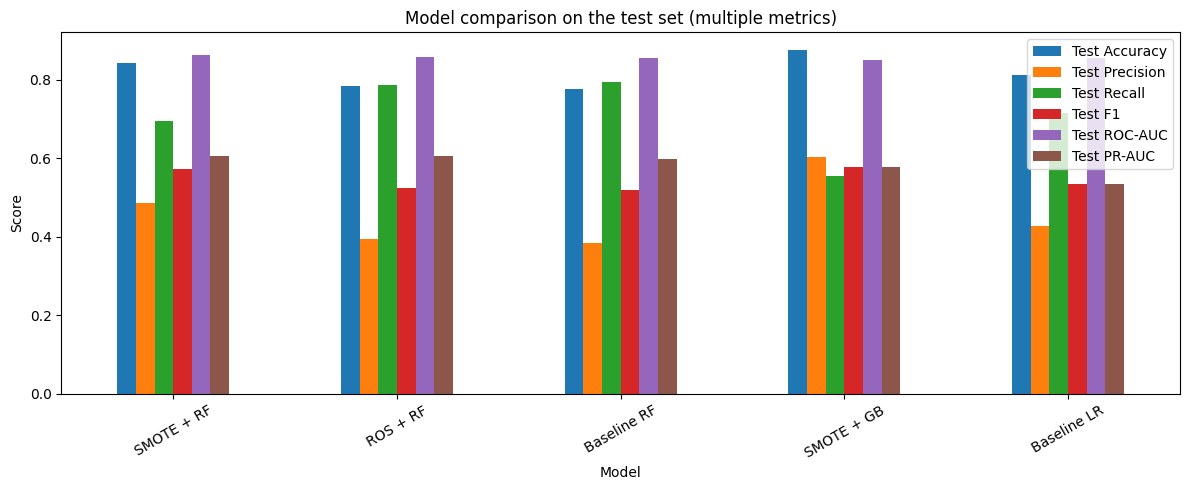

In [250]:
# =========================
# 2) Visual comparison (helps with unbalanced classes)
# =========================
import os

metrics_to_plot = ["Test Accuracy", "Test Precision", "Test Recall", "Test F1", "Test ROC-AUC", "Test PR-AUC"]

# Guard against empty results (e.g., if a previous cell didn't run)
if "eval_results_df" not in globals() or eval_results_df is None or eval_results_df.empty:
    raise ValueError("eval_results_df is empty. Run the evaluation cell(s) that build eval_results_df before plotting.")

# Keep only metrics that actually exist in the dataframe (avoids KeyError)
available_metrics = [m for m in metrics_to_plot if m in eval_results_df.columns]
if len(available_metrics) == 0:
    raise ValueError("No metric columns found in eval_results_df to plot.")

plot_df = eval_results_df.set_index("Model")[available_metrics]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, rot=30)
ax.set_title("Model comparison on the test set (multiple metrics)")
ax.set_ylabel("Score")
plt.tight_layout()

os.makedirs("../models", exist_ok=True)
plt.savefig("../models/model_comparison_metrics.png", dpi=200)
plt.show()


# ***Selecting the best model :***

### Problem Context
The task is a binary classification problem aiming to predict whether a video game
is a *Hit* or *Miss*. The dataset is **imbalanced**, with the *Hit* class representing
the minority. In such situations, relying solely on accuracy can be misleading, as
a model may achieve high accuracy by favoring the majority class.

Therefore, model selection must focus on metrics that properly reflect performance
on the minority class.

---

### Evaluation Metrics Considered

To select the best model, the following metrics were evaluated on the **test set**:

- **Precision**: measures how many predicted hits are actually hits.
- **Recall**: measures the ability of the model to correctly identify hit games.
- **F1-score**: harmonic mean of precision and recall, providing a balance between them.
- **ROC-AUC**: evaluates the model’s ability to separate classes across thresholds.
- **PR-AUC**: evaluates precision–recall performance across all thresholds and is
  particularly suitable for imbalanced datasets.

Among these metrics, **PR-AUC** and **Recall** were given higher importance due to the
imbalanced nature of the data and the objective of minimizing false negatives
(missed hit games).

---

### Rationale for Metric Prioritization

Although the F1-score is commonly used for imbalanced classification, it is computed
at a **single decision threshold** (typically 0.5). As a result, it does not fully
capture the model’s behavior across different thresholds.

In contrast, **PR-AUC** evaluates performance across all possible thresholds and
focuses on the positive (minority) class. This makes PR-AUC a more robust and reliable
metric for model comparison in imbalanced classification problems.

Recall was also emphasized, as failing to identify a hit game (false negative) is
considered more costly than incorrectly labeling a non-hit game as a hit.

---

### Model Comparison Summary

Multiple models and resampling strategies were evaluated, including:

- Baseline Logistic Regression/ Random Forest
- Baseline gradient boost / SMOTE + gradient boost
- Under-sampling + Random Forest
- SMOTE + Random Forest
- Random Over-Sampling (ROS) + Random Forest

While some models achieved higher accuracy or slightly higher F1-scores, the
**ROS + Random Forest** model consistently demonstrated:

- The **highest PR-AUC**, indicating superior minority-class ranking ability.
- High recall, reducing the number of missed hit games.
- Strong ROC-AUC, confirming good overall discriminative performance.

---

### Final Model Selection

Based on the above analysis, **SMOTE + Random Forest** was selected as the final model.

This decision was made because it provides the best trade-off between minority-class
detection and overall robustness, making it more suitable for deployment in an
imbalanced classification setting than models selected solely on accuracy or F1-score.

The selected model also supports probability predictions and feature importance
analysis, which further enables threshold tuning and model interpretability.


In [251]:
# =========================
# 3) Select the best model
# =========================
# Default: choose the model with the highest PR-AUC, then F1
# If you want to force a model, set: best_model_name = "SMOTE + LR" (example)

best_model_name = eval_results_df.iloc[0]["Model"]
best_model_row  = eval_results_df[eval_results_df["Model"] == best_model_name].iloc[0]
best_model      = models[best_model_name]

print("Selected best model:", best_model_name)
best_model_row


Selected best model: SMOTE + RF


,4
Model,SMOTE + RF
Test Accuracy,0.842495
Test Precision,0.486585
Test Recall,0.695122
Test F1,0.572453
Test ROC-AUC,0.862026
Test PR-AUC,0.605589


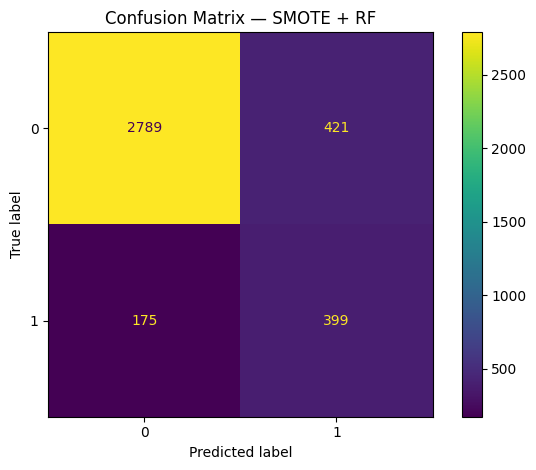


Classification Report:
              precision    recall  f1-score   support

           0     0.9410    0.8688    0.9035      3210
           1     0.4866    0.6951    0.5725       574

    accuracy                         0.8425      3784
   macro avg     0.7138    0.7820    0.7380      3784
weighted avg     0.8720    0.8425    0.8533      3784



In [252]:
# =========================
# 4) Confusion Matrix + Classification Report
# =========================
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=200)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


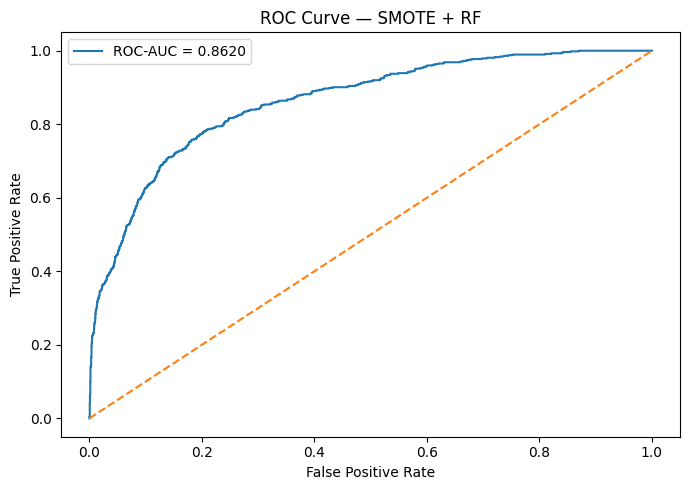

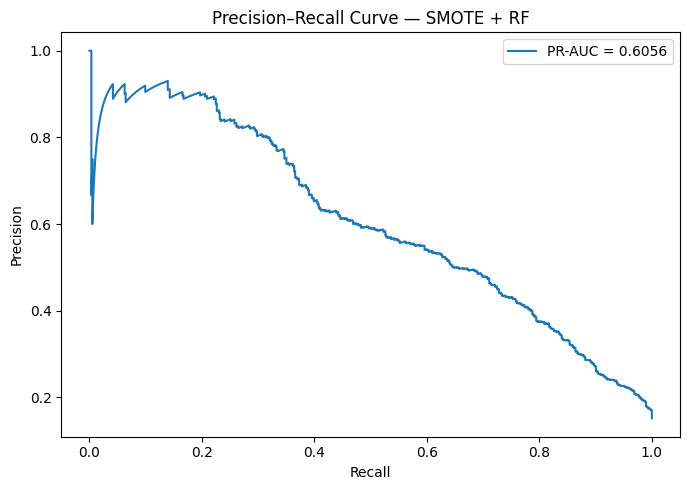

In [253]:
# =========================
# 5) ROC + Precision-Recall curves (probabilities)
# =========================
roc_auc = np.nan

if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {best_model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../models/roc_curve.png", dpi=200)
    plt.show()

    # PR curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {best_model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../models/pr_curve.png", dpi=200)
    plt.show()
else:
    print("This model does not support predict_proba(), so ROC/PR curves are skipped.")


## Using probabilities and threshold tuning

Many classifiers can output a **probability** of the positive class (Hit) via `predict_proba`.
This is useful because decision-making often requires **ranking and prioritization**, not only
a fixed yes/no decision.

- If the goal is to **catch as many hits as possible**, choose a **lower threshold** (higher recall, more false positives).
- If the goal is to **avoid false alarms**, choose a **higher threshold** (higher precision, more missed hits).

The ROC and Precision–Recall curves summarize performance across thresholds and help select an
operating point that matches the business objective.


## Model diagnosis: Overfitting vs underfitting

To ensure the selected model generalizes well, we diagnose **overfitting** and **underfitting**
using a **learning curve**. We compute performance on:
- **Training data** (how well the model fits the seen data)
- **Cross-validation data** (proxy for generalization to unseen data)

Because the dataset is imbalanced, we use **F1-score** for the learning curve.

**How to read the curve**
- **Large gap** (train >> validation): likely **overfitting**
- **Both low** (train and validation): likely **underfitting**
- **Close and high**: good generalization
- If validation performance keeps improving as data grows, collecting more data may help.


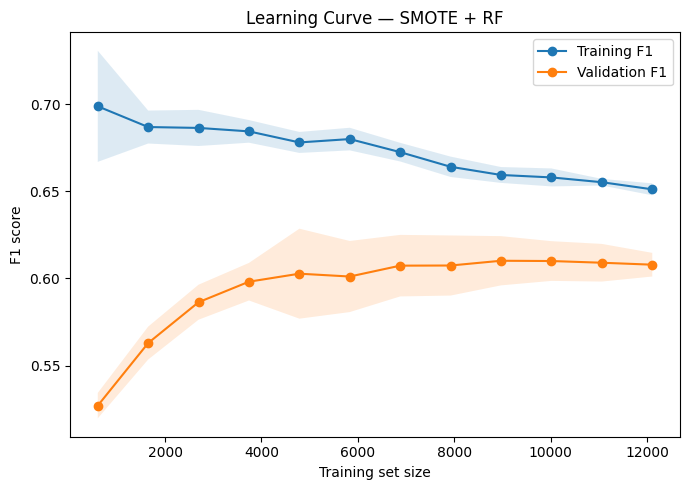

Learning curve summary:
  size=   605 | train_f1=0.699 | valid_f1=0.527
  size=  1651 | train_f1=0.687 | valid_f1=0.563
  size=  2696 | train_f1=0.686 | valid_f1=0.586
  size=  3742 | train_f1=0.684 | valid_f1=0.598
  size=  4788 | train_f1=0.678 | valid_f1=0.603
  size=  5833 | train_f1=0.680 | valid_f1=0.601
  size=  6879 | train_f1=0.672 | valid_f1=0.607
  size=  7925 | train_f1=0.664 | valid_f1=0.607
  size=  8970 | train_f1=0.659 | valid_f1=0.610
  size= 10016 | train_f1=0.658 | valid_f1=0.610
  size= 11062 | train_f1=0.655 | valid_f1=0.609
  size= 12108 | train_f1=0.651 | valid_f1=0.608


In [254]:
# =========================
# 6) Model diagnosis: Learning Curve (overfitting vs underfitting)
# =========================
# We use F1 as a robust metric under imbalance.
train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.05, 1.0, 12),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std  = valid_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, valid_mean, marker="o", label="Validation F1")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
plt.fill_between(train_sizes, valid_mean-valid_std, valid_mean+valid_std, alpha=0.15)
plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.title(f"Learning Curve — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig("../models/learning_curve.png", dpi=200)
plt.show()

print("Learning curve summary:")
for s, tr, va in zip(train_sizes, train_mean, valid_mean):
    print(f"  size={int(s):>6} | train_f1={tr:.3f} | valid_f1={va:.3f}")


### Interpretation

After plotting the learning curve, we check:
- whether the **validation F1-score** is close to the **training F1-score** (small gap → less overfitting),
- whether both curves reach a **reasonable level** (not underfitting),
- whether validation performance keeps increasing with more data (if yes, more data could help).

In this project, a small gap between training and validation curves indicates the model is
not severely overfitting, and stable validation performance suggests acceptable generalization.


,Feature,Importance
8,dev_success_rate,0.394093
1,has_critic_score,0.131350
0,critic_score,0.068587
54,console_PS3,0.031234
2,release_year,0.030783
3,game_age,0.030638
49,console_PC,0.028583
9,dev_game_count,0.028164
67,console_X360,0.023214
53,console_PS2,0.019591


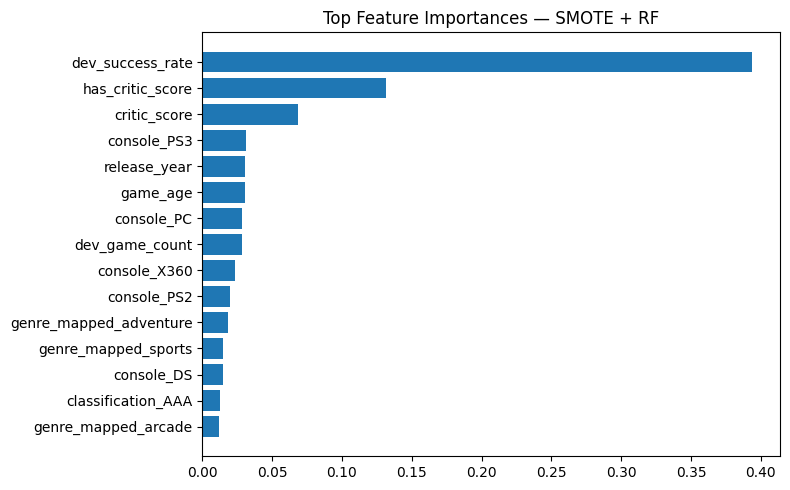

In [255]:
# =========================
# 7) Explainability: Feature importance (if supported)
# =========================
feature_imp_df = None

def get_feature_names(preprocessor):
    # Works for ColumnTransformer with OneHotEncoder
    feature_names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == "remainder" and trans == "drop":
            continue
        if hasattr(trans, "get_feature_names_out"):
            try:
                fn = trans.get_feature_names_out(cols)
            except TypeError:
                fn = trans.get_feature_names_out()
            feature_names.extend(fn)
        else:
            # passthrough numeric
            if isinstance(cols, (list, tuple, np.ndarray)):
                feature_names.extend([str(c) for c in cols])
            else:
                feature_names.append(str(cols))
    return np.array(feature_names, dtype=object)

# If the model is a Pipeline, try extracting the final estimator
final_estimator = best_model
preprocessor = None

if hasattr(best_model, "named_steps"):
    # common naming: "prep" then "model"
    for k, v in best_model.named_steps.items():
        if "columntransformer" in v.__class__.__name__.lower():
            preprocessor = v
    # fallback: first step often is the preprocessor
    if preprocessor is None:
        first_step = list(best_model.named_steps.values())[0]
        if "columntransformer" in first_step.__class__.__name__.lower():
            preprocessor = first_step
    final_estimator = list(best_model.named_steps.values())[-1]

if hasattr(final_estimator, "feature_importances_"):
    importances = final_estimator.feature_importances_

    if preprocessor is not None:
        names = get_feature_names(preprocessor)
        if len(names) == len(importances):
            feature_imp_df = pd.DataFrame({"Feature": names, "Importance": importances}).sort_values("Importance", ascending=False)
        else:
            feature_imp_df = pd.DataFrame({"Feature": [f"f{i}" for i in range(len(importances))],
                                           "Importance": importances}).sort_values("Importance", ascending=False)
    else:
        feature_imp_df = pd.DataFrame({"Feature": [f"f{i}" for i in range(len(importances))],
                                       "Importance": importances}).sort_values("Importance", ascending=False)

    display(feature_imp_df.head(15))

    plt.figure(figsize=(8, 5))
    top = feature_imp_df.head(15)[::-1]
    plt.barh(top["Feature"].astype(str), top["Importance"])
    plt.title(f"Top Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.savefig("../models/feature_importance_top15.png", dpi=200)
    plt.show()
else:
    print("Feature importance not available for this model.")


In [256]:
# =========================
# 8) Save best model + FINAL SUMMARY
# =========================
model_path = f"../models/{best_model_name.replace(' ', '_').lower()}_tuned.pkl"
joblib.dump(best_model, model_path)

print("\n" + "="*80)
print("FINAL MODEL EVALUATION SUMMARY")
print("="*80)
print(f"\nBest Model: {best_model_name}")
print(f"Model saved at: {model_path}")
print("\nPerformance Metrics:")
print(f"  - Accuracy:  {best_model_row['Test Accuracy']:.4f}")
print(f"  - Precision: {best_model_row['Test Precision']:.4f}")
print(f"  - Recall:    {best_model_row['Test Recall']:.4f}")
print(f"  - F1 Score:  {best_model_row['Test F1']:.4f}")
print(f"  - ROC-AUC:   {best_model_row['Test ROC-AUC']:.4f}")

print("\nKey Insights:")
print(f"  - The model correctly identifies {cm[1,1]} out of {cm[1,0]+cm[1,1]} hits ({cm[1,1]/(cm[1,0]+cm[1,1])*100:.1f}%)")
print(f"  - The model correctly identifies {cm[0,0]} out of {cm[0,0]+cm[0,1]} misses ({cm[0,0]/(cm[0,0]+cm[0,1])*100:.1f}%)")
print(f"  - ROC-AUC of {roc_auc:.4f} indicates {'good' if roc_auc > 0.75 else 'moderate' if roc_auc > 0.65 else 'fair'} discriminative ability")

if feature_imp_df is not None:
    top_3_features = feature_imp_df.head(3)['Feature'].tolist()
    print(f"\nTop 3 Most Important Features:")
    for i, feat in enumerate(top_3_features, 1):
        importance = feature_imp_df[feature_imp_df['Feature'] == feat]['Importance'].values[0]
        print(f"  {i}. {feat} ({importance:.4f})")

print("\nAll evaluation plots saved to: ../models/")
print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print("\nNext step: Run 5_deployment.ipynb to prepare model for deployment")



FINAL MODEL EVALUATION SUMMARY

Best Model: SMOTE + RF
Model saved at: ../models/smote_+_rf_tuned.pkl

Performance Metrics:
  - Accuracy:  0.8425
  - Precision: 0.4866
  - Recall:    0.6951
  - F1 Score:  0.5725
  - ROC-AUC:   0.8620

Key Insights:
  - The model correctly identifies 399 out of 574 hits (69.5%)
  - The model correctly identifies 2789 out of 3210 misses (86.9%)
  - ROC-AUC of 0.8620 indicates good discriminative ability

Top 3 Most Important Features:
  1. dev_success_rate (0.3941)
  2. has_critic_score (0.1314)
  3. critic_score (0.0686)

All evaluation plots saved to: ../models/

EVALUATION COMPLETE

Next step: Run 5_deployment.ipynb to prepare model for deployment


## 8. Discussion & Conclusion ( for the classification)
### Newly discovered insights
- **Success is multi-factor**: “Hit” status is not explained by one variable. The strongest
  signals combine **production strength** (developer/publisher history) and **quality proxies**
  (critic-related features when available), with additional effects from release timing and platform.
- **Class imbalance is the central challenge**: early experiments showed that accuracy can look
  acceptable while still failing to detect the minority “Hit” class. Therefore, we prioritized
  **PR-AUC**, **Recall**, and **F1 (Hit class)** for model selection and comparison.
- **Feature availability strongly affects performance**: before adding high-signal information
  such as critic-related features and publisher/developer aggregate indicators, performance was
  unstable and weaker. Including these features substantially improved the model’s ability to rank
  games by hit likelihood.
- **Publisher-known information is already useful**: an ablation-style comparison suggests that
  even using “publisher-side” features alone (publisher identity and publisher history indicators)
  can provide meaningful predictive signal, which supports early-stage decision-making before a
  critic score is available.

### Impact on decision-making
This model should be used as a **decision-support tool** rather than a strict yes/no classifier:

- Use **predicted probabilities** to **rank** upcoming games by expected hit likelihood.
- Prioritize **marketing budget, promotion effort, or portfolio investment** for titles with higher
  predicted hit probability.
- If missing a potential hit is costly, adjust the decision threshold to **increase recall**
  (accepting more false positives). If budget is limited and false alarms are expensive, tune the
  threshold toward higher precision.

### Limitations and future improvements
- **Data limitations**: key real-world drivers may be missing (marketing spend, pre-orders/wishlists,
  community size, social-media hype, competitor releases).
- **Critic score is not always available pre-release**: future versions should integrate alternative
  early signals (trailers, wishlists, sentiment, publisher marketing intensity).
- Future work: **threshold tuning** using PR curves, **cost-sensitive learning**, and **time-based
  splits** to simulate real forecasting when release dates are available.


## 9. Extension: Predicting Video Game Sales with Regression

In addition to predicting **Hit vs Non-Hit** (classification), we can also model **continuous sales values**
using **regression**. This supports more precise decision-making (e.g., budgeting, inventory planning, and marketing allocation).

###  Important note about leakage (very common mistake)
In many public video game datasets, `Global_Sales` is the **sum** of regional sales such as `NA_Sales`, `EU_Sales`, `JP_Sales`, and `Other_Sales`.
Therefore, using regional sales to predict `Global_Sales` would be **data leakage** (the model would be given the answer).

 In this regression section, we **do NOT** use any sales-by-region columns as features.  
We only use *safe* attributes that would be available at prediction time (platform, genre, publisher/developer info, critic/user metrics, release year, etc.).

---

### Goal
Train regression models to predict `Global_Sales` (or the available sales column in the dataset) and compare them using:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R²** (Explained variance)

Because sales are typically very skewed, we also try a **log1p** target transform (predicting `log(1+sales)`), then convert back.


In [184]:
print(train_df.columns.tolist())


['title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'has_critic_score', 'release_year', 'game_age', 'target', 'id', 'classification', 'released_games', 'unreleased_games', 'total_revenue', 'avg_revenue_per_game', 'median_revenue_per_game', 'pct_inhouse', 'action', 'adventure', 'arcade', 'casino', 'lifestyle', 'puzzle', 'racing', 'rpg', 'shooter', 'simulation', 'sports', 'strategy', 'tabletop', 'publisher_main_genre', 'publisher_second_genre', 'publisher_focus', 'publisher_revenue_tier', 'publisher_known', 'genre_mapped', 'publisher_genre_match', 'publisher_experience', 'era', 'dev_success_rate', 'dev_game_count', 'publisher_top10', 'developer_top10']


In [185]:
# =========================
# 9.1 Prepare data for regression (leakage-safe)
# =========================
from sklearn.model_selection import train_test_split

# --------------------------------------------------
# Detect target column name (from train_df ONLY)
# --------------------------------------------------
TARGET_CANDIDATES = ["global_sales", "total_sales", "GlobalSales", "globalSales"]

target_sales_col = next(
    (c for c in TARGET_CANDIDATES if c in train_df.columns),
    None
)

if target_sales_col is None:
    raise ValueError(
        "Could not find a global sales column. Expected one of: "
        + ", ".join(TARGET_CANDIDATES)
    )

print("Regression target column:", target_sales_col)

# --------------------------------------------------
# Build regression dataset from train + test (NO leakage)
#   - target is known historically
#   - features remain leakage-safe (NO sales inputs)
# --------------------------------------------------
df_reg = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# Drop rows with missing target
df_reg = df_reg.dropna(subset=[target_sales_col]).copy()

# --------------------------------------------------
# Leakage-safe feature set (NO sales columns)
# --------------------------------------------------
REG_NUM = [c for c in [
    "critic_score", "user_score", "critic_count", "user_count",
    "release_year", "game_age",
    "publisher_experience", "publisher_focus",
    "dev_success_rate", "dev_game_count",
] if c in df_reg.columns]

REG_CAT = [c for c in [
    "genre_mapped", "classification", "console",
    "publisher_top10", "developer_top10",
    # optional fallbacks if you kept raw columns
    "publisher", "developer"
] if c in df_reg.columns]

REG_FEATURES = REG_NUM + REG_CAT

print(" Regression numeric features:", REG_NUM)
print(" Regression categorical features:", REG_CAT)

# --------------------------------------------------
# Build X / y
# --------------------------------------------------
Xr = df_reg[REG_FEATURES].copy()
yr = df_reg[target_sales_col].astype(float)

# Ensure correct dtypes
for c in REG_CAT:
    Xr[c] = Xr[c].astype(object)

for c in REG_NUM:
    Xr[c] = pd.to_numeric(Xr[c], errors="coerce")

# --------------------------------------------------
# Train / test split (consistent with project)
# --------------------------------------------------
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr,
    yr,
    test_size=0.2,
    random_state=42
)

print("Xr_train:", Xr_train.shape, "Xr_test:", Xr_test.shape)


Regression target column: total_sales
✅ Regression numeric features: ['critic_score', 'release_year', 'game_age', 'publisher_experience', 'publisher_focus', 'dev_success_rate', 'dev_game_count']
✅ Regression categorical features: ['genre_mapped', 'classification', 'console', 'publisher_top10', 'developer_top10', 'publisher', 'developer']
Xr_train: (15135, 14) Xr_test: (3784, 14)


In [257]:
# =========================
# 9.2 Build regression pipelines + evaluate (handles NaNs)
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# ---------- Safety check (optional)
print("Missing values in regression features (train):")
print(Xr_train[REG_NUM + REG_CAT].isna().sum().sort_values(ascending=False).head(15))

# ---------- Preprocess: impute first, then encode
reg_preprocess = ColumnTransformer(
    transformers=[
        # Numeric: impute missing with median (robust to skew)
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), REG_NUM),

        # Categorical: impute missing with 'Unknown', then one-hot
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), REG_CAT),
    ],
    remainder="drop"
)

# Baseline: predict train median
baseline_pred = np.full(shape=len(yr_test), fill_value=np.median(yr_train), dtype=float)

def eval_reg(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results_reg = []
results_reg.append(eval_reg(yr_test, baseline_pred, "Baseline (train median)"))

regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=400, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

fitted_reg_models = {}

for name, reg in regressors.items():
    pipe = Pipeline([
        ("prep", reg_preprocess),
        ("model", reg),
    ])
    pipe.fit(Xr_train, yr_train)
    preds = pipe.predict(Xr_test)
    results_reg.append(eval_reg(yr_test, preds, name))
    fitted_reg_models[name] = pipe

reg_results_df = pd.DataFrame(results_reg).sort_values(by="MAE")
reg_results_df


Missing values in regression features (train):
publisher_focus         9686
critic_score               0
release_year               0
game_age                   0
publisher_experience       0
dev_success_rate           0
dev_game_count             0
genre_mapped               0
classification             0
console                    0
publisher_top10            0
developer_top10            0
publisher                  0
developer                  0
dtype: int64


,Model,MAE,RMSE,R2
3,Random Forest,0.236772,0.591651,0.524093
4,Extra Trees,0.239072,0.575911,0.549079
5,Gradient Boosting,0.266018,0.623294,0.471827
2,Ridge Regression,0.318486,0.674208,0.382016
0,Baseline (train median),0.319223,0.891380,-0.080228
1,Linear Regression,0.331909,0.678332,0.374431


## Regression Results Visualizations

To better understand regression model behavior beyond numerical metrics (MAE, RMSE, R²), we visualize:

- **Model comparison (MAE)** to quickly identify the most accurate regressor.
- **Predicted vs Actual** to evaluate calibration and systematic bias.
- **Residual distribution** to assess error spread and whether errors are centered around 0.
- **Feature importance** (when available) to extract decision-making insights (e.g., what drives sales).

,Model,MAE,RMSE,R2
3,Random Forest,0.236772,0.591651,0.524093
4,Extra Trees,0.239072,0.575911,0.549079
5,Gradient Boosting,0.266018,0.623294,0.471827
2,Ridge Regression,0.318486,0.674208,0.382016
0,Baseline (train median),0.319223,0.891380,-0.080228
1,Linear Regression,0.331909,0.678332,0.374431


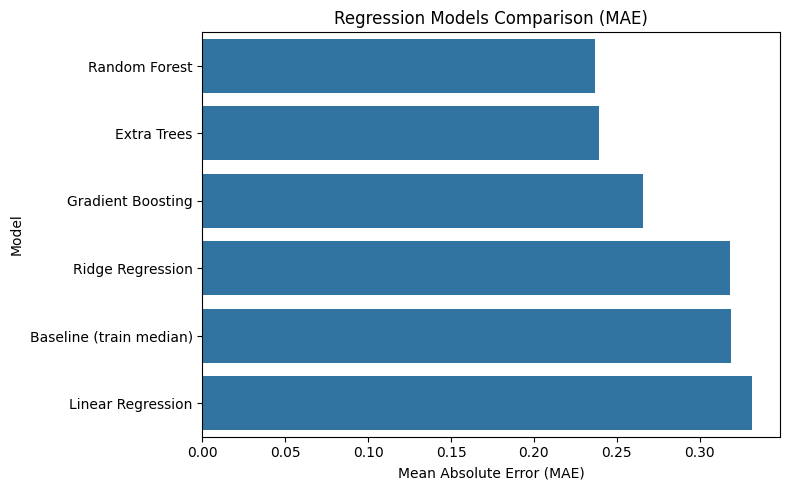

In [258]:
# =========================
# 9.3 Visualize regression model performance
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure reg_results_df exists
display(reg_results_df)

# --- 1) Model comparison by MAE ---
plt.figure(figsize=(8, 5))
sns.barplot(data=reg_results_df, x="MAE", y="Model")
plt.title("Regression Models Comparison (MAE)")
plt.xlabel("Mean Absolute Error (MAE)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

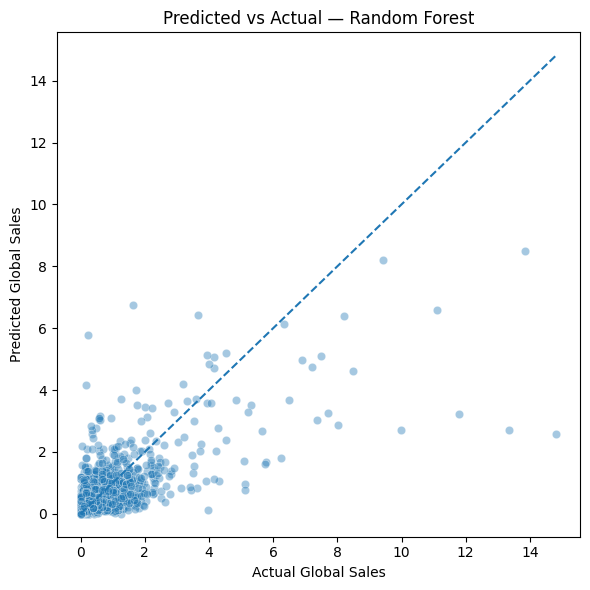

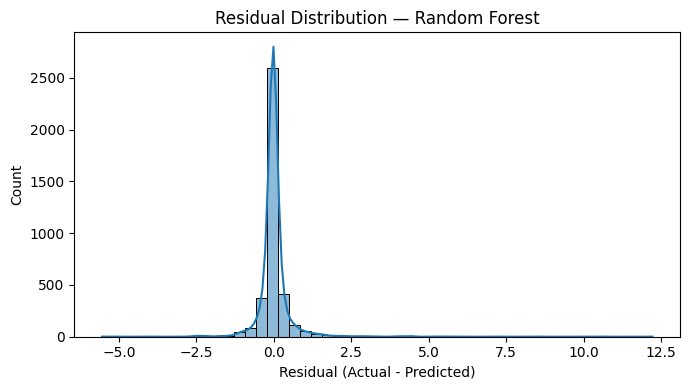

In [259]:
# --- 2) Predicted vs Actual + Residuals for best regression model ---
best_reg_name = reg_results_df.iloc[0]["Model"]

# fitted_reg_models should exist; if baseline is best (unlikely), take next best real model
if str(best_reg_name).startswith("Baseline"):
    best_reg_name = reg_results_df[~reg_results_df["Model"].astype(str).str.contains("Baseline")].iloc[0]["Model"]

best_reg_model = fitted_reg_models[best_reg_name]
best_preds = best_reg_model.predict(Xr_test)

# Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=yr_test, y=best_preds, alpha=0.4)
mn = float(min(yr_test.min(), np.min(best_preds)))
mx = float(max(yr_test.max(), np.max(best_preds)))
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual Global Sales")
plt.ylabel("Predicted Global Sales")
plt.title(f"Predicted vs Actual — {best_reg_name}")
plt.tight_layout()
plt.show()

# Residual distribution
residuals = yr_test - best_preds
plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.title(f"Residual Distribution — {best_reg_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

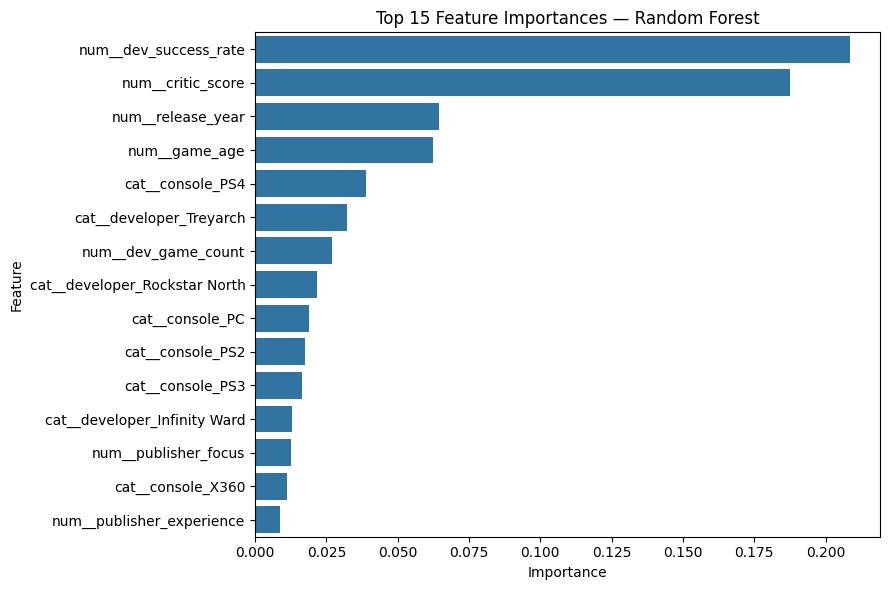

,Feature,Importance
5,num__dev_success_rate,0.208668
0,num__critic_score,0.187430
1,num__release_year,0.064367
2,num__game_age,0.062442
46,cat__console_PS4,0.038999
3120,cat__developer_Treyarch,0.032080
6,num__dev_game_count,0.026910
2670,cat__developer_Rockstar North,0.021857
41,cat__console_PC,0.019032
44,cat__console_PS2,0.017495


In [260]:
# --- 3) Feature importance (tree-based models only) ---
model_step = best_reg_model.named_steps.get("model", None)

if hasattr(model_step, "feature_importances_"):
    import pandas as pd

    importances = model_step.feature_importances_
    feature_names = best_reg_model.named_steps["prep"].get_feature_names_out()

    fi = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
            .sort_values("Importance", ascending=False)
            .head(15))

    plt.figure(figsize=(9, 6))
    sns.barplot(data=fi, x="Importance", y="Feature")
    plt.title(f"Top 15 Feature Importances — {best_reg_name}")
    plt.tight_layout()
    plt.show()

    display(fi)
else:
    print(f"Feature importance is not available for model: {best_reg_name}")

## Conclusion – Regression Models for Video Game Sales Prediction

In addition to the **Hit / Non-Hit classification**, we extended the project with a **regression task** to predict **Global Sales** (a continuous value). This supports decision-making in situations where stakeholders need *how much* a game might sell, not only whether it is likely to be a hit.

### Interpretation of the Compared Models

- **Linear Regression** provides a simple baseline and is easy to interpret, but it assumes a linear relationship between features and sales. This limits performance when sales depend on complex, non-linear interactions.
- **Ridge Regression** adds regularization to stabilize the linear model in the presence of correlated features, but it still keeps the linear assumption, so improvements may remain limited.
- **Random Forest Regressor** captures non-linear patterns and feature interactions well and is generally robust, making it a strong candidate for sales prediction.
- **Extra Trees Regressor** increases randomness in tree splitting, which can reduce variance and sometimes improve generalization compared to Random Forest.
- **Gradient Boosting Regressor** improves performance by sequentially correcting errors, but it can be sensitive to hyperparameters and may require careful tuning to avoid overfitting.

### Decision-Making Impact

A reliable sales prediction model can help publishers and studios:

- **Forecast demand** and plan inventory/supply (physical or digital distribution),
- **Optimize marketing spend** by prioritizing games with higher predicted sales,
- **Support pricing and release strategies**, especially around high-competition periods,
- Provide explainability (when tree-based feature importance is available) to identify which factors drive sales.

### Notes on Validity

For this regression extension, we used a **leakage-safe feature set**, meaning we did **not** use regional sales columns (e.g., NA_Sales, EU_Sales, JP_Sales, Other_Sales) as inputs to predict Global_Sales because Global_Sales is derived from them.

In [261]:
# =========================
# 9.3 Optional: log1p target transform (often improves skewed sales prediction)
# =========================
from sklearn.base import clone

yr_train_log = np.log1p(yr_train)
yr_test_log  = np.log1p(yr_test)

results_reg_log = []
results_reg_log.append(
    eval_reg(yr_test, np.expm1(np.full_like(yr_test_log, np.median(yr_train_log))), "Baseline log1p (train median)")
)

for name, reg in regressors.items():
    pipe = Pipeline([
        ("prep", reg_preprocess),
        ("model", clone(reg)),
    ])
    pipe.fit(Xr_train, yr_train_log)
    preds_log = pipe.predict(Xr_test)
    preds = np.expm1(preds_log)  # back-transform
    results_reg_log.append(eval_reg(yr_test, preds, f"{name} (log1p target)"))

reg_results_log_df = pd.DataFrame(results_reg_log).sort_values(by="MAE")
reg_results_log_df


,Model,MAE,RMSE,R2
3,Random Forest (log1p target),0.227086,0.589707,0.527217
4,Extra Trees (log1p target),0.232065,0.588097,0.529794
5,Gradient Boosting (log1p target),0.252335,0.662076,0.404056
2,Ridge Regression (log1p target),0.273361,0.702758,0.328568
1,Linear Regression (log1p target),0.279522,0.700470,0.332934
0,Baseline log1p (train median),0.319223,0.891380,-0.080228


Best regression model: Random Forest (log1p target)


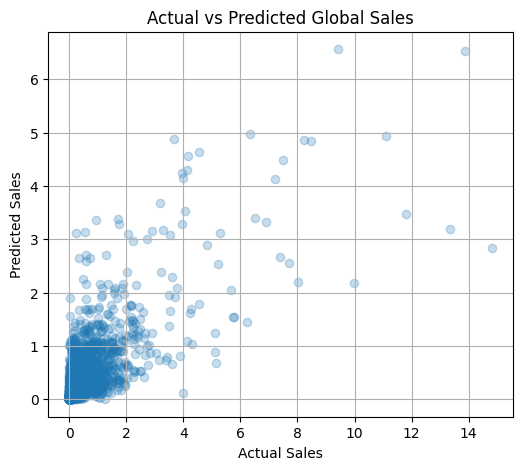

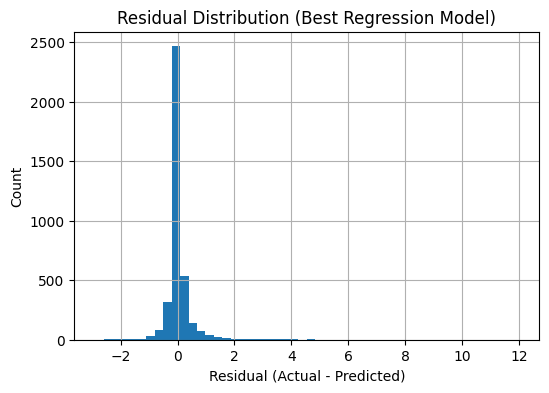

In [262]:
# =========================
# 9.4 Visual diagnostics: Actual vs Predicted (best regression model)
# =========================
import matplotlib.pyplot as plt

# Choose best by MAE from the log1p table if it exists; otherwise from raw table
use_log = True
best_reg_row = reg_results_log_df.iloc[0] if 'reg_results_log_df' in globals() else reg_results_df.iloc[0]
best_reg_name = best_reg_row["Model"]
print("Best regression model:", best_reg_name)

# Get the fitted pipeline corresponding to the best model name (strip suffix if log1p)
base_name = best_reg_name.replace(" (log1p target)", "")
best_pipe = fitted_reg_models.get(base_name)

if best_pipe is None:
    print("Best model was a baseline; skipping scatter plot.")
else:
    # If best is log1p, refit on log target for consistent predictions
    if "(log1p target)" in best_reg_name:
        from sklearn.base import clone
        best_pipe = Pipeline([("prep", reg_preprocess), ("model", clone(regressors[base_name]))])
        best_pipe.fit(Xr_train, yr_train_log)
        pred_sales = np.expm1(best_pipe.predict(Xr_test))
    else:
        pred_sales = best_pipe.predict(Xr_test)

    # Scatter plot
    plt.figure(figsize=(6, 5))
    plt.scatter(yr_test, pred_sales, alpha=0.25)
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.title("Actual vs Predicted Global Sales")
    plt.grid(True)
    plt.show()

    # Residual histogram
    residuals = yr_test - pred_sales
    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=50)
    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Count")
    plt.title("Residual Distribution (Best Regression Model)")
    plt.grid(True)
    plt.show()


### How this complements the Hit/Non-Hit classifier

- **Classification** answers: *Will the game be a hit?* (useful for prioritization)
- **Regression** answers: *How much will it sell?* (useful for budgeting, inventory, and revenue forecasting)

1. A classifier to identify likely hits,
2. A regressor to estimate expected sales for those candidates.
